In [464]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import re

METHOD:

In this notebook we will start by loading all the data in the order of:

- Percipitation

- River discharge

- Evaporation

- Crop Coefficients

- Areas


Afterwards we will define other parameters before building our water balance model. In the end we will visualize results

PERCIPITATION DATA

In [465]:
percipitation_black = pd.read_csv(r"precipitation data volta\mswep\Black Volta_-2.75_9.55.csv", index_col=0, parse_dates=True)
percipitation_lake = pd.read_csv(r"precipitation data volta\mswep\Lake Volta_0.05_6.45.csv", index_col=0, parse_dates=True)
percipitation_oti = pd.read_csv(r"precipitation data volta\mswep\Oti_0.15_8.45.csv", index_col=0, parse_dates=True)
percipitation_pendjari = pd.read_csv(r"precipitation data volta\mswep\Pendjari_1.15_11.15.csv", index_col=0, parse_dates=True)


In [466]:
percip_blackvolta = percipitation_black /1000
percip_lakevolta = percipitation_lake /1000
percip_oti = percipitation_oti /1000
percip_pendjari = percipitation_pendjari /1000

print(percip_pendjari.head(-5))


            precipitation
time                     
1979-01-01            0.0
1979-01-02            0.0
1979-01-03            0.0
1979-01-04            0.0
1979-01-05            0.0
...                   ...
2017-10-22            0.0
2017-10-23            0.0
2017-10-24            0.0
2017-10-25            0.0
2017-10-26            0.0

[14179 rows x 1 columns]


DISCHARGE DATA

In [467]:
path = r"discharge data volta\discharge in columns.xlsx"
raw = pd.read_excel(path, header=None)

def is_number(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def join_tokens(row, cols):
    toks = [row[c] for c in cols if pd.notna(row[c])]
    s = " ".join(map(str, toks))
    s = re.sub(r"\s+", " ", s).strip()
    return s

records = []
cur_river = None
cur_station = None

for _, row in raw.iterrows():
    # Header rows: first cell is not numeric -> contains river/station fragments
    if not is_number(row[0]):
        cur_river = join_tokens(row, range(0, 6))   # cols 0-5
        cur_station = join_tokens(row, range(6, 11)) # cols 6-10
        continue

    meta = row[11]
    if pd.isna(meta) or cur_river is None:
        continue

    # meta like "2 21977" -> r=2, month=2, year=1977
    parts = str(meta).split()
    if len(parts) != 2:
        continue
    r = int(parts[0])
    my = int(parts[1])
    month = my // 10000
    year = my % 10000

    # values live in cols 0..10 (10 values for row 1/2, up to 11 for row 3)
    vals = pd.to_numeric(row.loc[0:10], errors="coerce").dropna().to_list()
    start_day = (r - 1) * 10 + 1

    for i, v in enumerate(vals):
        day = start_day + i
        # build date; invalid dates (e.g., Feb 30) become NaT and are skipped
        dt = pd.to_datetime({"year": [year], "month": [month], "day": [day]}, errors="coerce")[0]
        if pd.isna(dt):
            continue

        if v == 9999:
            v = np.nan

        records.append({
            "Date": dt,
            "River": cur_river,
            "Station": cur_station,
            "Row": r,
            "Discharge": v
        })

df = pd.DataFrame(records).set_index("Date").sort_index()




['BOUGOU RIBA', 'MOU HO UN (VO LTA NO IRE)', 'NAKANB E (VOL TA BLA NCHE)', 'NAZINO N (VOL TA ROU GE)', 'PENDJA RI', 'SINGOU', 'VOLTA NOIRE']
Earliest river discharge data point: 1952-06-01 00:00:00
Latest river discharge data point: 1993-09-30 00:00:00
Earliest Volta Rouge discharge data point: 1977-01-01 00:00:00
Latest Volta Rouge discharge data point: 1983-09-30 00:00:00


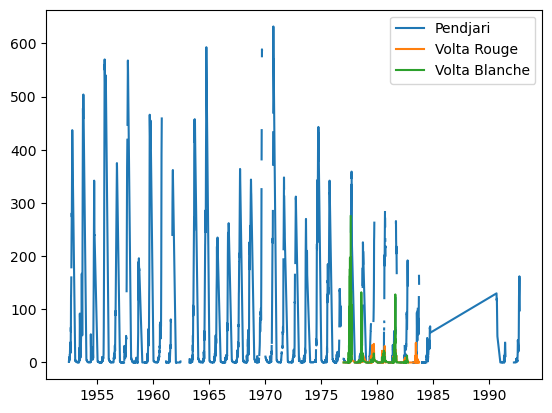

In [468]:
river_names = list(river_dfs.keys())[:]
print(river_names)
river_pendjari, river_voltarouge, river_voltablanche = (river_dfs[river_names[4]], river_dfs[river_names[3]], river_dfs[river_names[2]])

plt.plot(river_pendjari.index, river_pendjari["Discharge"], label="Pendjari")
plt.plot(river_voltarouge.index, river_voltarouge["Discharge"], label="Volta Rouge")
plt.plot(river_voltablanche.index, river_voltablanche["Discharge"], label="Volta Blanche")
plt.legend()

#earliest data point in the river discharge data
print("Earliest river discharge data point:", df.index.min())
print("Latest river discharge data point:", df.index.max())

#earliest data point in volta rouge data
print("Earliest Volta Rouge discharge data point:", river_voltarouge.index.min())
print("Latest Volta Rouge discharge data point:", river_voltarouge.index.max())

In [469]:
def make_river_design_year(
    river_df: pd.DataFrame,
    discharge_col: str = "Discharge",
    agg: str = "median",          # "median" or "mean"
    smooth_window: int = 7,       # set 0 to disable smoothing
    units: str = "m3/s"           # for metadata only
) -> pd.Series:
    """
    Returns a Series indexed by 'MM-DD' with typical discharge for that day-of-year.
    Handles missing days by interpolation and optionally smooths seasonality.
    """

    s = river_df[discharge_col].copy()

    # Ensure daily datetime index (normalize) and combine duplicates per day if needed
    s.index = pd.to_datetime(s.index).normalize()
    s = s.groupby(level=0).mean()

    # Group by month-day across all years
    md = s.index.strftime("%m-%d")
    if agg == "mean":
        dy = s.groupby(md).mean()
    else:
        dy = s.groupby(md).median()

    # Make sure we have a full 365-day template (you can extend to 366 if you want leap support)
    template_md = pd.date_range("2001-01-01", "2001-12-31", freq="D").strftime("%m-%d")
    dy = dy.reindex(template_md)

    # Fill missing MM-DD values (caused by gaps in records)
    dy = dy.astype(float).interpolate(limit_direction="both")

    # Optional smoothing (circular smoothing so Jan 1 connects to Dec 31)
    if smooth_window and smooth_window > 1:
        pad = smooth_window * 2
        dy_pad = pd.concat([dy.iloc[-pad:], dy, dy.iloc[:pad]])
        dy_smooth = dy_pad.rolling(smooth_window, center=True, min_periods=1).mean()
        dy = dy_smooth.iloc[pad:-pad]
        dy.index = template_md

    dy.name = f"Q_design_{units}"
    return dy


# --- Build design years for your three rivers ---
Q_pendjari_md     = make_river_design_year(river_pendjari, agg="median", smooth_window=7)
Q_voltarouge_md   = make_river_design_year(river_voltarouge, agg="median", smooth_window=7)
Q_voltablanche_md = make_river_design_year(river_voltablanche, agg="median", smooth_window=7)

# --- Save to CSV (MM-DD index as a column) ---
def export_md_series_to_csv(md_series: pd.Series, file_path: str, md_col="MM-DD", value_col="Discharge_m3s"):
    out = md_series.reset_index()
    out.columns = [md_col, value_col]
    out.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

export_md_series_to_csv(Q_pendjari_md,     "river_designyear_pendjari_m3s.csv")
export_md_series_to_csv(Q_voltarouge_md,   "river_designyear_voltarouge_m3s.csv")
export_md_series_to_csv(Q_voltablanche_md, "river_designyear_voltablanche_m3s.csv")

Q_pendjari_md = pd.read_csv("river_designyear_pendjari_m3s.csv").set_index("MM-DD")["Discharge_m3s"]
print(Q_voltarouge_md.head())

Saved: river_designyear_pendjari_m3s.csv
Saved: river_designyear_voltarouge_m3s.csv
Saved: river_designyear_voltablanche_m3s.csv
01-01    0.428571
01-02    0.285714
01-03    0.142857
01-04    0.000000
01-05    0.000000
Name: Q_design_m3/s, dtype: float64


EVAPORATION DATA

In [470]:
df_evaporation = pd.read_excel('evaporation_daily_design_year.xlsx', index_col=0, parse_dates=True)
df_evaporation = df_evaporation.copy() / 1000 # convert from mm/day to m/day

CROP DATA

In [471]:
crop_data = pd.read_excel("cropdata.xlsx")
print(crop_data.head())
cd = crop_data.copy()
cd.columns = cd.columns.str.strip()

if "crop" not in cd.columns:
    if "Unnamed: 0" in cd.columns:
        cd = cd.rename(columns={"Unnamed: 0": "crop"})
    else:
        cd = cd.rename(columns={cd.columns[0]: "crop"})

cd["crop"] = cd["crop"].astype(str).str.strip()

rename_map = {
    # fix typos here if your file has them
    "Kc end": "Kc_end",
    "Lc_initial (days)": "Lc_initial_days",
    "Lc_develop (days)": "Lc_develop_days",
    "Lc_mid (days)": "Lc_mid_days",
    "Lc_end (days)": "Lc_end_days",
    "start month": "start_month",
    "Kc_intitial": "Kc_initial",           # your earlier typo
    "Lc_intitial (days)": "Lc_initial_days" # your earlier typo
}
cd = cd.rename(columns={k: v for k, v in rename_map.items() if k in cd.columns})

month_map = {m: i for i, m in enumerate(
    ["January","February","March","April","May","June","July","August","September","October","November","December"], start=1
)}
cd["start_month_num"] = cd["start_month"].map(month_map)
# ---------- 2) Create an MM-DD index (365 days, no leap day) ----------
base = pd.date_range("2001-01-01", "2001-12-31", freq="D")  # 2001 is non-leap
md_index = base.strftime("%m-%d")  # strings like '01-01' ... '12-31'

# ---------- 3) Build daily Kc curve on MM-DD index ----------
def kc_design_md_for_crop(row, kc_offseason=0.0):
    # Start with offseason everywhere
    kc = pd.Series(kc_offseason, index=md_index, dtype=float)

    kc_ini = float(row["Kc_initial"])
    kc_mid = float(row["Kc_mid"])
    kc_end = float(row["Kc_end"])

    L_ini = int(row["Lc_initial_days"]) if pd.notna(row["Lc_initial_days"]) else 0
    L_dev = int(row["Lc_develop_days"]) if pd.notna(row["Lc_develop_days"]) else 0
    L_mid = int(row["Lc_mid_days"]) if pd.notna(row["Lc_mid_days"]) else 0
    L_end = int(row["Lc_end_days"]) if pd.notna(row["Lc_end_days"]) else 0

    season_len = L_ini + L_dev + L_mid + L_end
    if season_len <= 0:
        return kc

    start_month = int(row["start_month_num"])
    start_date = pd.Timestamp(year=2001, month=start_month, day=1)

    # Create the season dates in the base non-leap year, and wrap if needed
    season_dates = pd.date_range(start_date, periods=season_len, freq="D")

    part1 = np.full(L_ini, kc_ini)
    part2 = np.linspace(kc_ini, kc_mid, num=L_dev, endpoint=False) if L_dev > 0 else np.array([])
    part3 = np.full(L_mid, kc_mid)
    part4 = np.linspace(kc_mid, kc_end, num=L_end, endpoint=True) if L_end > 0 else np.array([])
    kc_vals = np.concatenate([part1, part2, part3, part4])

    for d, v in zip(season_dates, kc_vals):
        # wrap to within 2001
        wrapped = base[(d - base[0]).days % len(base)]
        kc[wrapped.strftime("%m-%d")] = float(v)

    return kc

kc_by_crop = {row["crop"]: kc_design_md_for_crop(row, kc_offseason=0.0) for _, row in cd.iterrows()}
kc_df_md = pd.DataFrame(kc_by_crop)  # 365 rows, index='MM-DD'

# ---------- 4) Combine to one overall Kc ----------
weights = {
    "Cassava": 0.33,
    "Rice": 0.11,
    "Maize": 0.39,
    "Yam": 0.17
}
w = pd.Series(weights, dtype=float)
w = w / w.sum()

kc_combined_md = (kc_df_md[w.index] * w).sum(axis=1)
kc_combined_md.name = "Kc_combined"

print(kc_combined_md.head(10)) #coefficients for each day of the year
print("\nLength:", len(kc_combined_md)) 

  Unnamed: 0  Kc_intitial  Kc_mid  Kc_end  Lc_intitial (days)  \
0    Cassava         0.30    0.80    0.30                20.0   
1       Rice         1.05    1.20    0.90                30.0   
2      Maize          NaN    1.15    1.05                20.0   
3        Yam          NaN    0.95    0.95                 NaN   

   Lc_develop (days)  Lc_mid (days)  Lc_end (days)  Lc_total (days)  \
0               40.0           90.0           60.0              210   
1               30.0           60.0           30.0              150   
2               25.0           25.0           10.0               80   
3                NaN            NaN            NaN              300   

  start month  
0    November  
1        June  
2        June  
3    December  
01-01    0.264
01-02    0.264
01-03    0.264
01-04    0.264
01-05    0.264
01-06    0.264
01-07    0.264
01-08    0.264
01-09    0.264
01-10    0.264
Name: Kc_combined, dtype: float64

Length: 365


POLYGON AREAS

In [472]:
percipitation_area = pd.read_csv("area_precipitation_volta.csv", index_col=1)

#area of each catchment in m2
df_Acatch = percipitation_area["area_km2"]
area_blackvolta = df_Acatch["Black_volta"] * 1e6
area_lakevolta = df_Acatch["Lake_volta"] * 1e6
area_oti = df_Acatch["Oti"] * 1e6
area_pendjari = df_Acatch["Pendjari"] * 1e6
##area that is cropland within a catchment in m2
df_Airr = percipitation_area["Crop_area_m2"]
crop_blackvolta = df_Airr["Black_volta"]
crop_lakevolta = df_Airr["Lake_volta"]
crop_oti = df_Airr["Oti"]
crop_pendjari = df_Airr["Pendjari"]
##percentage of catchment area that is cropland
crop_blackvolta_per = crop_blackvolta / area_blackvolta
crop_lakevolta_per = crop_lakevolta / area_lakevolta
crop_oti_per = crop_oti / area_oti
crop_pendjari_per = crop_pendjari / area_pendjari
print(crop_blackvolta_per, crop_lakevolta_per, crop_oti_per, crop_pendjari_per)

0.0862945690343757 0.06416867942302204 0.20988613468441694 0.08923156434315048


SUBBASINS
- irrigation area
- catchment area
- which polygon does it fall into?


In [473]:
########### LOAD THE SUBBASINS FROM QGIS DATA FROM THE REST HERE ############
catchments = pd.read_excel("Catchment area Final.xlsx", index_col=0)
catchments.head()
#make a new column for crop area in m2
catchments["crop_area_m2"] = catchments["Areas (m^2)"] * [crop_blackvolta_per, crop_pendjari_per, crop_oti_per, crop_oti_per]
catchments.head()

,Areas (m^2),Region,Precipitation poligon,crop_area_m2
Catchments,,,,
1,5.083914e+09,Upper west,black volta,4.387142e+08
2,3.999386e+09,Upper east,pendjari,3.568715e+08
3,5.352351e+09,North east region (assumption),Oti,1.123384e+09
4,8.686731e+09,Northern,Oti,1.823224e+09


In [474]:

area_catchment = catchments["Areas (m^2)"].iloc[0]
area_irrigation = catchments["crop_area_m2" ].iloc[0]

print(area_catchment, area_irrigation)


5083914154.4 438714180.9617105


In [475]:
#parameters for the reservoir design model
SEC_PER_DAY = 86400.0
Cr = 0.34 #runoff coefficient
k = 0 * SEC_PER_DAY #seepage coefficient m/day
reservoir_area = np.linspace(10000, 9000000, num=10)

NOW THE MODEL IN ORDER TO DECIDE THE MINIMUM SURFACE AREA OF THE RESERVOIR IN ORDER TO ALLOW FOR A MAXIMUM OF 10 DAYS OF NO IRRIGATION (EG. 10 CONSECUTIVE DAYS THAT THERE IS NO WATER IN THE RESERVOIR)

In [476]:
SEC_PER_DAY = 86400.0

def volume(area_m2):
    volume = 0.00857 * (area_m2)**1.4367
    return volume #m3

def Rcatch(Cr, Percip, Acatch):
    Rcatch = Cr * Percip * Acatch
    return Rcatch #runoff from catchment in m3/day

def Pdir(Percip, area):
    Pdir = Percip * area
    return Pdir #direct precipitation on reservoir in m3/day

def E(evap, area):
    E = evap * area
    return E #evaporation from reservoir in m3/day

def seep(k, area, L=3):
    seep = k * area * (volume(area) / area) / L
    return seep #seepage loss from reservoir in m3/day

def Dirr(percip, E, Kc, eff_rain=1):
    # Dirr in m/day
    return ((Kc * E - eff_rain * percip)/ 0.75).clip(lower=0.0) #irrigation demand in m/day #the 0.75 is an effiency factor to account for losses in the irrigation system

def abstract(Dirr, Airr):
    abstract = Dirr * Airr
    return abstract #abstraction for irrigation in m3/day

def delta_s(area, percip, Acatch, Dirr, Airr, evap, L=3, Rriver=0.0, Cr=Cr, K=k):
    delta_s = (Rcatch(Cr, percip, Acatch) + Rriver + Pdir(percip, area)) - E(evap, area) - seep(K, area, L) - abstract(Dirr, Airr)
    return delta_s #change in storage in m3/day


In [477]:

SEC_PER_DAY = 86400.0

class ReservoirDesignModel:
    """
    Changes vs your current version:
      1) Reliability metric based on unmet demand (or deficit fraction), not only Supply==0.
      2) River diversion includes intake capacity (Qdiv_max_m3s) and optional stop-when-full.
      3) Adds diagnostic columns (inflows/losses).
      4) Optional soil moisture bucket for irrigation demand (more hydrologically realistic).
    """

    def __init__(
        self,
        percip_df,                 # daily, m/day
        evap_df,                   # daily, m/day (used as ET0 for crops AND as reservoir evaporation driver unless you split it)
        kc_combined_md,            # Series indexed by "MM-DD"
        area_catchment,            # m2
        area_irrigation,           # m2
        Cr,                        # runoff coefficient (-)
        k,                         # seepage coefficient (your units)
        L=3,
        eff_rain=0.4,

        # river
        river_q=None,              # Series: DatetimeIndex or "MM-DD"; values m3/s
        diversion=0.0,             # float, Series (datetime), or callable(date,S,cap,row)->0..1
        Qdiv_max_m3s=None,         # NEW: cap on diverted flow (m3/s). None = no cap
        stop_diversion_when_full=True,  # NEW

        # alignment
        how_align="inner",
        fill_missing=None,
        daily_duplicate_agg="mean",

        # reliability metric
        deficit_frac_threshold=0.0,  # NEW: 0.0 = any unmet is failure; 0.2 => failure if >=20% unmet

        # optional soil bucket
        use_soil_bucket=False,   # NEW
        TAW_mm=120.0,            # total available water in root zone (mm)
        p=0.5,                   # depletion fraction
        infil_eff=0.6,           # fraction of rainfall entering root zone (simplified)
        Dr0_mm=None,             # initial depletion (mm). None => start at RAW
    ):
        self.area_catchment = float(area_catchment)
        self.area_irrigation = float(area_irrigation)
        self.Cr = float(Cr)
        self.k = float(k)
        self.L = float(L)
        self.eff_rain = float(eff_rain)

        self.river_q = river_q
        self.diversion = diversion
        self.Qdiv_max_m3s = Qdiv_max_m3s
        self.stop_diversion_when_full = bool(stop_diversion_when_full)

        self.deficit_frac_threshold = float(deficit_frac_threshold)

        self.use_soil_bucket = bool(use_soil_bucket)
        self.TAW_mm = float(TAW_mm)
        self.p = float(p)
        self.RAW_mm = self.p * self.TAW_mm
        self.infil_eff = float(infil_eff)
        self.Dr0_mm = self.RAW_mm if Dr0_mm is None else float(Dr0_mm)

        # ---- prepare P and Ev ----
        P = self._to_series(percip_df)
        P = self._ensure_daily_unique(P, how=daily_duplicate_agg)
        P.name = "percip_m_day"

        Ev = self._to_series(evap_df)
        Ev = self._ensure_daily_unique(Ev, how=daily_duplicate_agg)
        Ev.name = "evap_m_day"

        df = pd.concat([P, Ev], axis=1, join=how_align).sort_index()

        if fill_missing is not None:
            if fill_missing in ("ffill", "bfill"):
                df = df.fillna(method=fill_missing)
            else:
                df = df.fillna(float(fill_missing))

        df = df.dropna()

        # ---- map Kc design-year ----
        kc_md = kc_combined_md
        if isinstance(kc_md, pd.DataFrame):
            kc_md = kc_md.iloc[:, 0]
        if not isinstance(kc_md, pd.Series):
            kc_md = pd.Series(kc_md)
        kc_md = kc_md.copy()
        kc_md.index = kc_md.index.astype(str)

        df["Kc"] = self._map_md_to_dates(kc_md, df.index)

        # ---- river series normalize if provided ----
        if self.river_q is not None:
            if isinstance(self.river_q, pd.DataFrame):
                self.river_q = self.river_q.iloc[:, 0]
            if not isinstance(self.river_q, pd.Series):
                raise TypeError("river_q must be a pandas Series or 1-column DataFrame.")
            if isinstance(self.river_q.index, pd.DatetimeIndex):
                self.river_q = self._ensure_daily_unique(self.river_q, how="mean")
            else:
                self.river_q.index = self.river_q.index.astype(str)

        self.df = df

        # ---- sanity guards (protect against unit blow-ups) ----
        if self.area_irrigation > 1e10 or self.area_catchment > 1e12:
            raise ValueError(
                f"Areas look unrealistic (m²). Airr={self.area_irrigation:.3e}, Acatch={self.area_catchment:.3e}."
            )

    # ---------------- helpers ----------------
    def _to_series(self, x):
        if isinstance(x, pd.Series):
            return x
        if isinstance(x, pd.DataFrame):
            if x.shape[1] > 1:
                return x.mean(axis=1)
            return x.iloc[:, 0]
        raise TypeError("Expected pandas Series or DataFrame.")

    def _ensure_daily_unique(self, s, how="mean"):
        s = s.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]
        s.index = s.index.normalize()
        s = s.sort_index()
        if s.index.has_duplicates:
            s = s.groupby(level=0).sum() if how == "sum" else s.groupby(level=0).mean()
        return s.astype(float)

    def _map_md_to_dates(self, md_series, target_dates):
        if not md_series.index.is_unique:
            md_series = md_series.groupby(level=0).mean()
        md = pd.Index(target_dates.strftime("%m-%d"))
        out = md.map(md_series)
        if pd.isna(out).any():
            leap_mask = (md == "02-29") & pd.isna(out)
            if leap_mask.any():
                if "02-28" in md_series.index:
                    out = pd.Series(out)
                    out.loc[leap_mask] = float(md_series.loc["02-28"])
                    out = out.values
        return pd.Series(out, index=target_dates, dtype=float)

    def _Dirr_scalar(self, P_m_day, Ev_m_day, Kc):
        sP = pd.Series([P_m_day])
        sE = pd.Series([Ev_m_day])
        sK = pd.Series([Kc])
        return float(Dirr(sP, sE, sK, eff_rain=self.eff_rain).iloc[0])  # m/day

    def _river_q_for_date(self, dt):
        if self.river_q is None:
            return 0.0
        q = self.river_q
        if isinstance(q.index, pd.DatetimeIndex):
            d = pd.to_datetime(dt).normalize()
            return float(q.loc[d]) if d in q.index else 0.0
        md = pd.to_datetime(dt).strftime("%m-%d")
        return float(q.loc[md]) if md in q.index else 0.0

    def _diversion_frac_for_date(self, dt, storage, cap, row):
        d = pd.to_datetime(dt).normalize()
        if callable(self.diversion):
            return float(np.clip(self.diversion(d, storage, cap, row), 0.0, 1.0))
        if isinstance(self.diversion, (int, float, np.floating)):
            return float(np.clip(self.diversion, 0.0, 1.0))
        if isinstance(self.diversion, pd.Series):
            if isinstance(self.diversion.index, pd.DatetimeIndex) and d in self.diversion.index:
                return float(np.clip(self.diversion.loc[d], 0.0, 1.0))
        return 0.0

    # ---------------- simulation ----------------
    def simulate(self, area_m2, S0_frac=1.0):
        area_m2 = float(area_m2)
        cap_m3 = float(volume(area_m2))
        S = cap_m3 * float(S0_frac)

        # soil bucket state
        Dr_mm = self.Dr0_mm  # depletion (mm). 0=full, TAW=empty

        n = len(self.df)
        out = {
            "Demand_m3_day": np.zeros(n),
            "Supply_m3_day": np.zeros(n),
            "Unmet_m3_day":  np.zeros(n),
            "Storage_m3":    np.zeros(n),

            "InflowCatch_m3_day": np.zeros(n),
            "InflowRain_m3_day":  np.zeros(n),
            "InflowRiver_m3_day": np.zeros(n),

            "LossEvap_m3_day": np.zeros(n),
            "LossSeep_m3_day": np.zeros(n),

            "RiverDiversion_m3_day": np.zeros(n),
        }

        for i, (dt, row) in enumerate(self.df.iterrows()):
            P  = float(row["percip_m_day"])  # m/day
            Ev = float(row["evap_m_day"])    # m/day (ET0 driver)
            Kc = float(row["Kc"])

            # ----- irrigation demand -----
            if not self.use_soil_bucket:
                dirr_m_day = self._Dirr_scalar(P, Ev, Kc)  # m/day
                Dm3 = float(abstract(dirr_m_day, self.area_irrigation))
            else:
                # Soil bucket demand (more hydrologically realistic)
                Pmm = P * 1000.0
                ETcmm = (Kc * Ev) * 1000.0
                Ieff = self.infil_eff * Pmm

                Dr_mm = np.clip(Dr_mm + ETcmm - Ieff, 0.0, self.TAW_mm)

                Irrmm = max(0.0, Dr_mm - self.RAW_mm)  # refill back to RAW
                Dr_mm = max(0.0, Dr_mm - Irrmm)

                Dm3 = float(abstract(Irrmm / 1000.0, self.area_irrigation))

            out["Demand_m3_day"][i] = Dm3

            # ----- inflows -----
            inflow_catch = float(Rcatch(self.Cr, P, self.area_catchment))
            inflow_rain  = float(Pdir(P, area_m2))
            inflow_base  = inflow_catch + inflow_rain

            out["InflowCatch_m3_day"][i] = inflow_catch
            out["InflowRain_m3_day"][i]  = inflow_rain

            # river diversion
            Q_m3s = self._river_q_for_date(dt)
            frac  = self._diversion_frac_for_date(dt, S, cap_m3, row)

            Qdiv = frac * Q_m3s
            if self.Qdiv_max_m3s is not None:
                Qdiv = min(Qdiv, float(self.Qdiv_max_m3s))
            if self.stop_diversion_when_full and S >= cap_m3:
                Qdiv = 0.0

            add_m3 = Qdiv * SEC_PER_DAY
            out["RiverDiversion_m3_day"][i] = add_m3
            out["InflowRiver_m3_day"][i] = add_m3

            inflow_total = inflow_base + add_m3

            # ----- losses -----
            loss_evap = float(E(Ev, area_m2))
            loss_seep = float(seep(self.k, area_m2, self.L))
            out["LossEvap_m3_day"][i] = loss_evap
            out["LossSeep_m3_day"][i] = loss_seep
            loss = loss_evap + loss_seep

            # ----- balance -----
            available = S + inflow_total - loss
            if available < 0:
                available = 0.0

            Sm3 = min(Dm3, available)
            out["Supply_m3_day"][i] = Sm3
            out["Unmet_m3_day"][i]  = Dm3 - Sm3

            S = available - Sm3
            if S > cap_m3:
                S = cap_m3
            out["Storage_m3"][i] = S

        sim = pd.DataFrame(index=self.df.index, data=out)
        sim["percip_m_day"] = self.df["percip_m_day"].values
        sim["evap_m_day"]   = self.df["evap_m_day"].values
        sim["Kc"]           = self.df["Kc"].values
        sim["Capacity_m3"]  = cap_m3
        sim["Reservoir_area_m2"] = area_m2
        return sim

    # ---------------- reliability metric ----------------
    def max_consecutive_failure_days(self, sim_df):
        """
        Failure definition:
          frac_unmet = Unmet/Demand on demand-days.
          failure if frac_unmet > deficit_frac_threshold.
        """
        d = sim_df["Demand_m3_day"].to_numpy()
        u = sim_df["Unmet_m3_day"].to_numpy()

        frac_unmet = np.zeros_like(u, dtype=float)
        mask = d > 0
        frac_unmet[mask] = u[mask] / d[mask]

        failure = frac_unmet > self.deficit_frac_threshold

        max_run = run = 0
        for v in failure:
            if v:
                run += 1
                max_run = max(max_run, run)
            else:
                run = 0
        return int(max_run)

    def find_min_area(self, area_candidates_m2, max_consecutive_failure_days=10, S0_frac=1.0):
        results = []
        for area_m2 in area_candidates_m2:
            sim = self.simulate(area_m2, S0_frac=S0_frac)
            max_run = self.max_consecutive_failure_days(sim)

            results.append({
                "area_m2": float(area_m2),
                "area_ha": float(area_m2) / 10000.0,
                "capacity_m3": float(volume(float(area_m2))),
                "max_consec_failure_days": int(max_run),
                "total_unmet_m3": float(sim["Unmet_m3_day"].sum()),
                "total_river_diverted_m3": float(sim["RiverDiversion_m3_day"].sum()),
            })

            if max_run <= max_consecutive_failure_days:
                return float(area_m2), sim, pd.DataFrame(results)

        return None, None, pd.DataFrame(results)

In [478]:
oti_T5 = pd.read_csv(
    "oti_T5.csv",
    parse_dates=["time"],
    index_col="time"
)

oti_T5_future = pd.read_csv("oti_T5_future.csv", parse_dates=["time"], index_col="time")


In [479]:
oti_T50 = pd.read_csv("oti_T50_current.csv", parse_dates=["time"], index_col="time")
oti_T50_future = pd.read_csv("oti_T50_future.csv", parse_dates=["time"], index_col="time")

In [480]:
#parameters for the reservoir design model
Cr = 0.34 #runoff coefficient
k = 0 #seepage coefficient m/day
reservoir_area = np.linspace(10000, 50000000, num=100) #candidate reservoir areas from 1 to 5000 ha

In [481]:
########### LOAD THE SUBBASINS FROM QGIS DATA FROM THE REST HERE ############
catchments = pd.read_excel("Catchment area Final.xlsx", index_col=0)
catchments["Areas (m^2)"].iloc[-1] = catchments["Areas (m^2)"].iloc[-1] * 0.5

# #make a new column for crop area in m2
catchments["crop_area_m2"] = catchments["Areas (m^2)"] * [crop_blackvolta_per, crop_pendjari_per, crop_oti_per, crop_oti_per]

# #link river data to subbasins
catchments["River"] = ["Q_voltarouge_md", "Q_voltablanche_md", "Q_voltablanche_md", "Q_pendjari_md"]
catchments.head()

C:\Users\ellis\AppData\Local\Temp\ipykernel_6668\3438204106.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  catchments["Areas (m^2)"].iloc[-1] = catchments["Areas (m^2)"].iloc[-1] * 0.5
C:\Users\ellis\AppData\Local\Temp\ipykernel_6668\34

,Areas (m^2),Region,Precipitation poligon,crop_area_m2,River
Catchments,,,,,
1,5.083914e+09,Upper west,black volta,4.387142e+08,Q_voltarouge_md
2,3.999386e+09,Upper east,pendjari,3.568715e+08,Q_voltablanche_md
3,5.352351e+09,North east region (assumption),Oti,1.123384e+09,Q_voltablanche_md
4,4.343365e+09,Northern,Oti,9.116122e+08,Q_pendjari_md


For Oti_T5 current scenario for the originally defined catchments:


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,2.244840e+08,6.737349e+06
1,5.149495e+05,51.494949,1.377441e+06,59,1.642983e+08,6.926194e+06
2,1.019899e+06,101.989899,3.676841e+06,56,1.230724e+08,7.177989e+06
3,1.524848e+06,152.484848,6.552735e+06,52,9.592229e+07,7.553829e+06
4,2.029798e+06,202.979798,9.883216e+06,47,7.201882e+07,7.785257e+06
5,2.534747e+06,253.474747,1.359921e+07,42,5.602133e+07,7.903749e+06
6,3.039697e+06,303.969697,1.765481e+07,35,4.179072e+07,8.277737e+06
7,3.544646e+06,354.464646,2.201670e+07,27,3.265489e+07,8.277737e+06
8,4.049596e+06,404.959596,2.665933e+07,18,2.372425e+07,8.277737e+06
9,4.554545e+06,455.454545,3.156231e+07,7,1.430847e+07,8.533234e+06


Best area: 4554545 m² (455.45 ha)
Capacity: 31562312 m³
Max consecutive no-supply days: 7


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,1.770108e+08,1.581120e+07
1,5.149495e+05,51.494949,1.377441e+06,58,1.212417e+08,1.608706e+07
2,1.019899e+06,101.989899,3.676841e+06,55,8.773511e+07,1.669341e+07
3,1.524848e+06,152.484848,6.552735e+06,49,6.317916e+07,1.780241e+07
4,2.029798e+06,202.979798,9.883216e+06,42,4.431958e+07,1.894104e+07
5,2.534747e+06,253.474747,1.359921e+07,35,3.045020e+07,1.924282e+07
6,3.039697e+06,303.969697,1.765481e+07,26,2.241493e+07,1.979733e+07
7,3.544646e+06,354.464646,2.201670e+07,15,1.405451e+07,1.979733e+07
8,4.049596e+06,404.959596,2.665933e+07,3,5.172095e+06,2.031387e+07


Best area: 4049596 m² (404.96 ha)
Capacity: 26659328 m³
Max consecutive no-supply days: 3


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,61,6.600086e+08,1.774872e+07
1,5.149495e+05,51.494949,1.377441e+06,60,5.880950e+08,1.849485e+07
2,1.019899e+06,101.989899,3.676841e+06,59,5.036792e+08,1.939834e+07
3,1.524848e+06,152.484848,6.552735e+06,58,4.432644e+08,1.947240e+07
4,2.029798e+06,202.979798,9.883216e+06,56,4.023214e+08,2.059899e+07
5,2.534747e+06,253.474747,1.359921e+07,54,3.715500e+08,2.106000e+07
6,3.039697e+06,303.969697,1.765481e+07,52,3.465759e+08,2.142658e+07
7,3.544646e+06,354.464646,2.201670e+07,51,3.226772e+08,2.200793e+07
8,4.049596e+06,404.959596,2.665933e+07,51,3.008073e+08,2.200793e+07
9,4.554545e+06,455.454545,3.156231e+07,51,2.853556e+08,2.200793e+07


Best area: 10613939 m² (1061.39 ha)
Capacity: 106428450 m³
Max consecutive no-supply days: 10


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,61,4.745232e+08,9.426487e+07
1,5.149495e+05,51.494949,1.377441e+06,60,4.037006e+08,9.715865e+07
2,1.019899e+06,101.989899,3.676841e+06,57,3.307951e+08,9.905513e+07
3,1.524848e+06,152.484848,6.552735e+06,54,2.875360e+08,9.905513e+07
4,2.029798e+06,202.979798,9.883216e+06,48,2.580206e+08,1.016471e+08
5,2.534747e+06,253.474747,1.359921e+07,40,2.332134e+08,1.023896e+08
6,3.039697e+06,303.969697,1.765481e+07,36,2.104929e+08,1.032536e+08
7,3.544646e+06,354.464646,2.201670e+07,32,1.907087e+08,1.032536e+08
8,4.049596e+06,404.959596,2.665933e+07,28,1.776654e+08,1.041176e+08
9,4.554545e+06,455.454545,3.156231e+07,23,1.681720e+08,1.041435e+08


Best area: 6069394 m² (606.94 ha)
Capacity: 47678844 m³
Max consecutive no-supply days: 7
for Oti_T5 the sizes of the reservoirs needed for the catchments are (in ha):[455.4545454545455, 404.95959595959596, 1061.3939393939395, 606.939393939394]


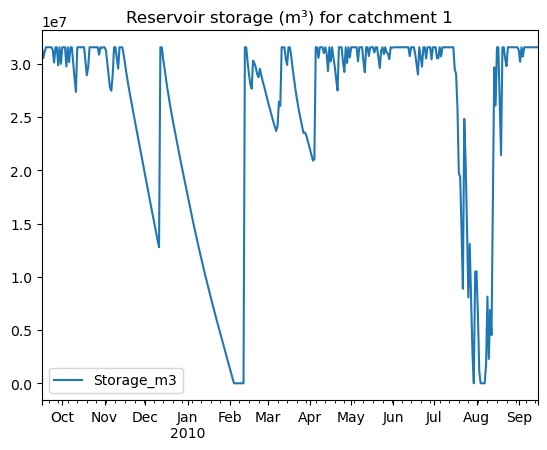

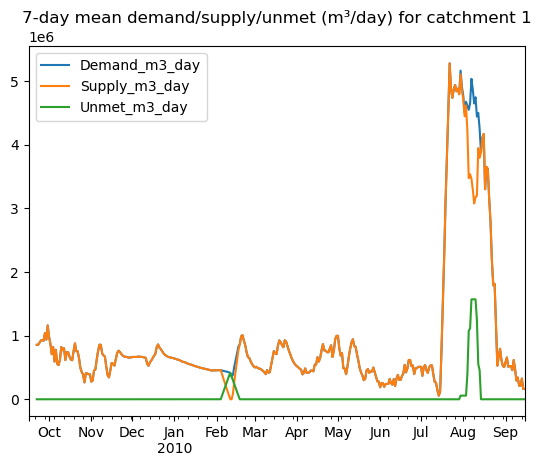

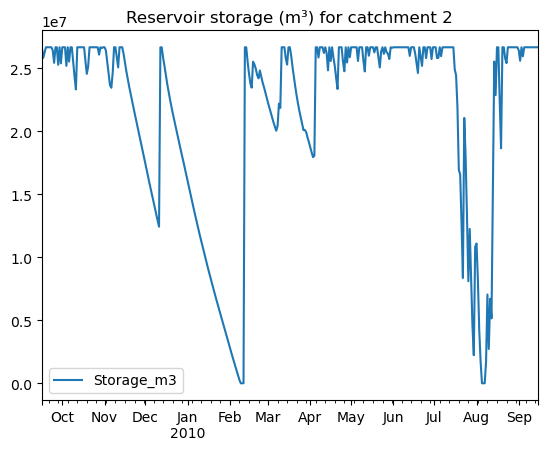

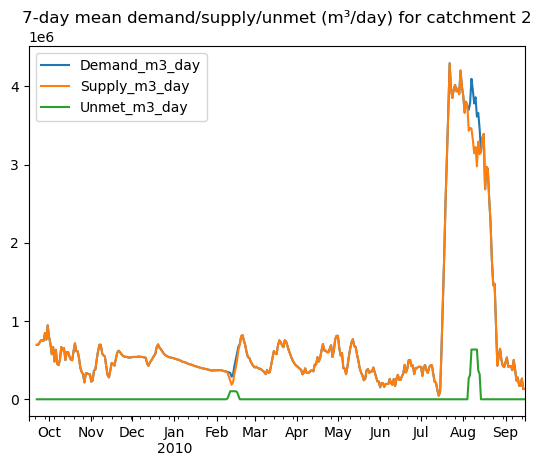

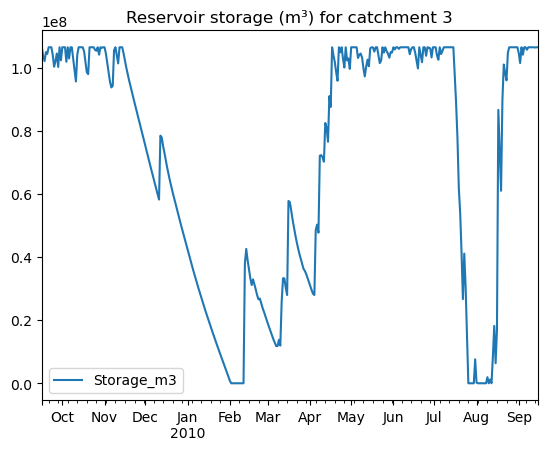

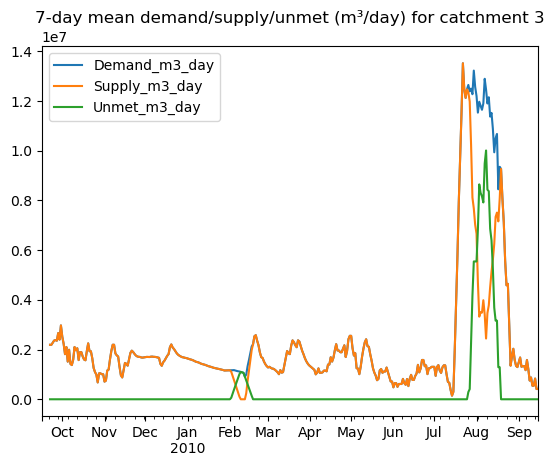

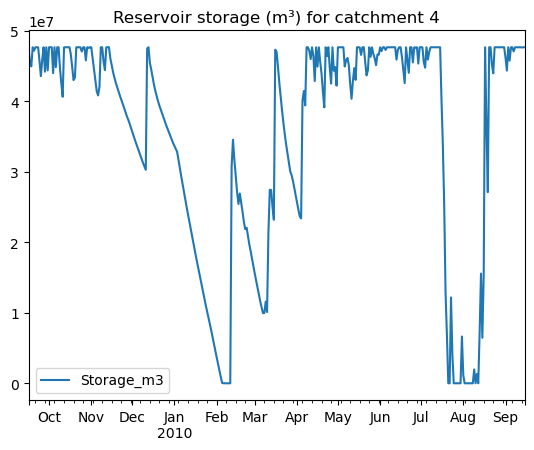

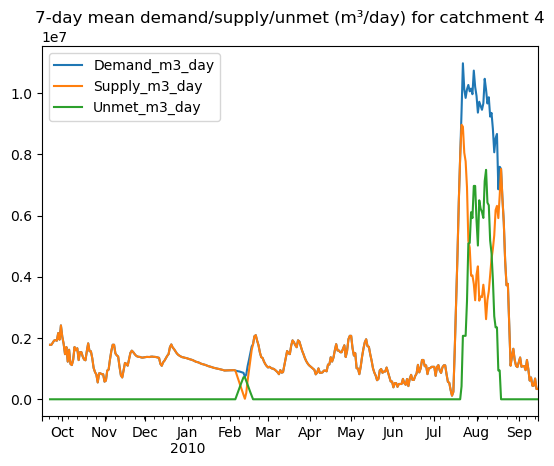

In [482]:
print("For Oti_T5 current scenario for the originally defined catchments:")

surfaceareas = []
for i in range(len(catchments)):
    area_catchment = catchments["Areas (m^2)"].iloc[i]
    area_irrigation = catchments["crop_area_m2"].iloc[i]
    model = ReservoirDesignModel(
    percip_df=oti_T5,     # or your scenario precip
    evap_df=df_evaporation,      # aligned ET0 series
    kc_combined_md=kc_combined_md,
    area_catchment=area_catchment,
    area_irrigation=area_irrigation,
    Cr=Cr,
    k=k,
    river_q=eval(catchments["River"].iloc[i]),   # design-year river (m3/s)
    diversion=0.30,
    Qdiv_max_m3s=10.0,            # IMPORTANT
    stop_diversion_when_full=True,
    deficit_frac_threshold=0.2,  # or 0.0
    use_soil_bucket=False        # set True when you're ready
    )

    best_area_m2, sim_best, summary = model.find_min_area(
        reservoir_area,
        max_consecutive_failure_days=10,
        S0_frac=1.0
        )

    display(summary)
    surfaceareas.append(best_area_m2)

    if best_area_m2 is None:
        print("No feasible area found in the candidate set.")
    else:
        print(f"Best area: {best_area_m2:.0f} m² ({best_area_m2/10000:.2f} ha)")
        print(f"Capacity: {volume(best_area_m2):.0f} m³")
        print(f"Max consecutive no-supply days: {model.max_consecutive_failure_days(sim_best)}")

        sim_best[["Storage_m3"]].plot(title=f"Reservoir storage (m³) for catchment {catchments.index[i]}")
        sim_best[["Demand_m3_day","Supply_m3_day","Unmet_m3_day"]].rolling(7).mean().plot(
            title=f"7-day mean demand/supply/unmet (m³/day) for catchment {catchments.index[i]}"
        )


print(f"for Oti_T5 the sizes of the reservoirs needed for the catchments are (in ha):{[area/10000 for area in surfaceareas]}")

For Oti_T5 future scenario for the originally defined catchments:


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,2.223209e+08,6.624411e+06
1,5.149495e+05,51.494949,1.377441e+06,59,1.622574e+08,6.813257e+06
2,1.019899e+06,101.989899,3.676841e+06,56,1.212015e+08,7.065051e+06
3,1.524848e+06,152.484848,6.552735e+06,52,9.351619e+07,7.440891e+06
4,2.029798e+06,202.979798,9.883216e+06,47,6.960336e+07,7.672320e+06
5,2.534747e+06,253.474747,1.359921e+07,42,5.206262e+07,7.903749e+06
6,3.039697e+06,303.969697,1.765481e+07,35,3.647437e+07,8.018537e+06
7,3.544646e+06,354.464646,2.201670e+07,27,2.735535e+07,8.277737e+06
8,4.049596e+06,404.959596,2.665933e+07,18,1.842335e+07,8.277737e+06
9,4.554545e+06,455.454545,3.156231e+07,7,9.006208e+06,8.296251e+06


Best area: 4554545 m² (455.45 ha)
Capacity: 31562312 m³
Max consecutive no-supply days: 7


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,1.755838e+08,1.531779e+07
1,5.149495e+05,51.494949,1.377441e+06,58,1.198641e+08,1.552886e+07
2,1.019899e+06,101.989899,3.676841e+06,55,8.665923e+07,1.620000e+07
3,1.524848e+06,152.484848,6.552735e+06,49,6.154048e+07,1.730901e+07
4,2.029798e+06,202.979798,9.883216e+06,42,4.180191e+07,1.845874e+07
5,2.534747e+06,253.474747,1.359921e+07,35,2.672466e+07,1.895215e+07
6,3.039697e+06,303.969697,1.765481e+07,26,1.822835e+07,1.925393e+07
7,3.544646e+06,354.464646,2.201670e+07,15,9.866570e+06,1.980843e+07
8,4.049596e+06,404.959596,2.665933e+07,3,9.827923e+05,1.980843e+07


Best area: 4049596 m² (404.96 ha)
Capacity: 26659328 m³
Max consecutive no-supply days: 3


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,61,6.565272e+08,1.732104e+07
1,5.149495e+05,51.494949,1.377441e+06,60,5.857061e+08,1.790239e+07
2,1.019899e+06,101.989899,3.676841e+06,59,4.990266e+08,1.939834e+07
3,1.524848e+06,152.484848,6.552735e+06,58,4.384923e+08,1.947240e+07
4,2.029798e+06,202.979798,9.883216e+06,56,3.953611e+08,2.004449e+07
5,2.534747e+06,253.474747,1.359921e+07,54,3.648884e+08,2.059899e+07
6,3.039697e+06,303.969697,1.765481e+07,52,3.382468e+08,2.090078e+07
7,3.544646e+06,354.464646,2.201670e+07,51,3.143518e+08,2.148213e+07
8,4.049596e+06,404.959596,2.665933e+07,51,2.924729e+08,2.194313e+07
9,4.554545e+06,455.454545,3.156231e+07,51,2.764226e+08,2.194313e+07


Best area: 10613939 m² (1061.39 ha)
Capacity: 106428450 m³
Max consecutive no-supply days: 10


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,61,4.727603e+08,9.366747e+07
1,5.149495e+05,51.494949,1.377441e+06,60,4.021780e+08,9.582315e+07
2,1.019899e+06,101.989899,3.676841e+06,57,3.274182e+08,9.934025e+07
3,1.524848e+06,152.484848,6.552735e+06,54,2.836842e+08,9.934025e+07
4,2.029798e+06,202.979798,9.883216e+06,48,2.525875e+08,1.010683e+08
5,2.534747e+06,253.474747,1.359921e+07,40,2.264549e+08,1.018107e+08
6,3.039697e+06,303.969697,1.765481e+07,36,2.037564e+08,1.018107e+08
7,3.544646e+06,354.464646,2.201670e+07,32,1.839760e+08,1.035387e+08
8,4.049596e+06,404.959596,2.665933e+07,28,1.704333e+08,1.035387e+08
9,4.554545e+06,455.454545,3.156231e+07,23,1.609380e+08,1.035646e+08


Best area: 6069394 m² (606.94 ha)
Capacity: 47678844 m³
Max consecutive no-supply days: 7
for Oti_T5 future scenario the sizes of the reservoirs needed for the catchments are (in ha):[455.4545454545455, 404.95959595959596, 1061.3939393939395, 606.939393939394]


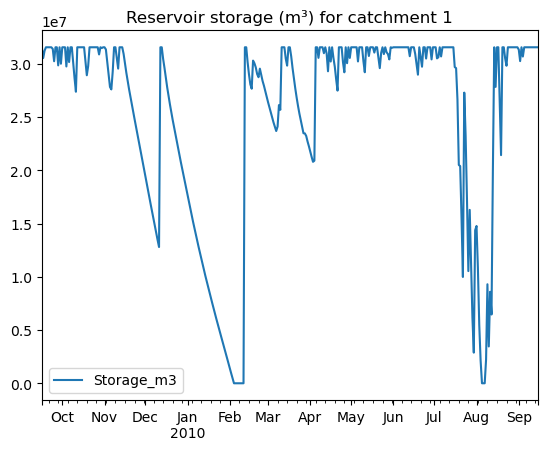

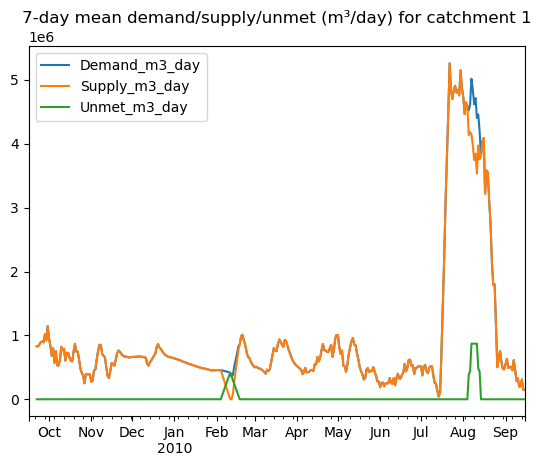

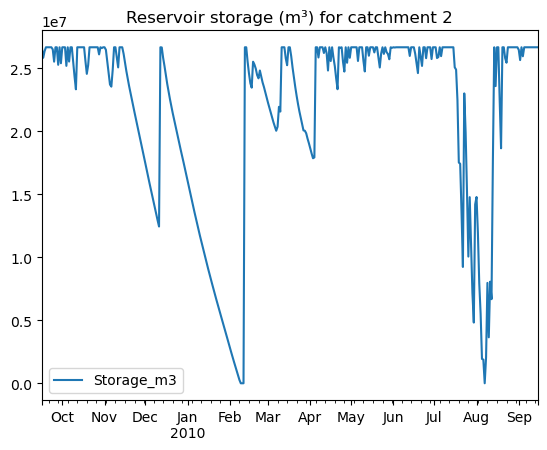

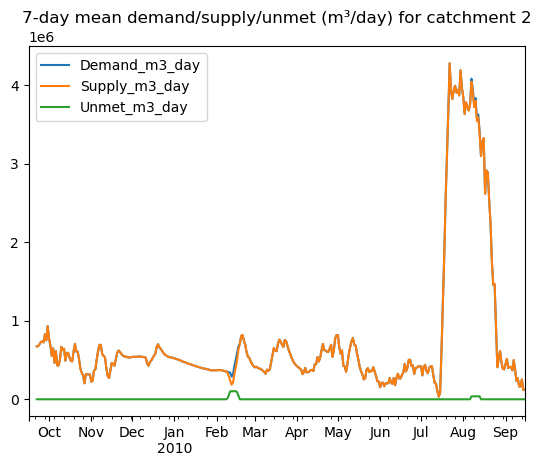

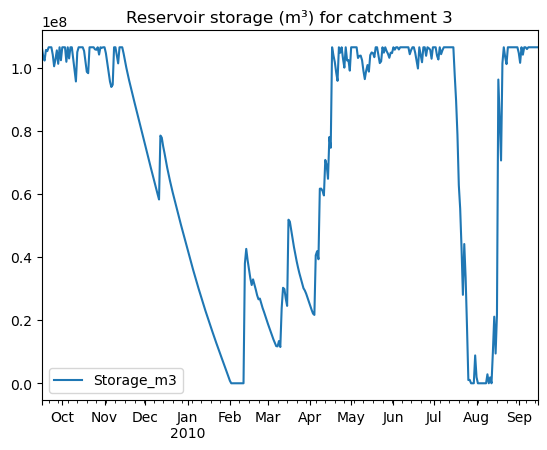

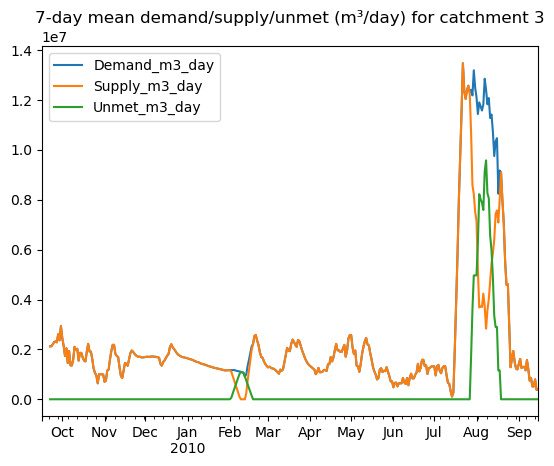

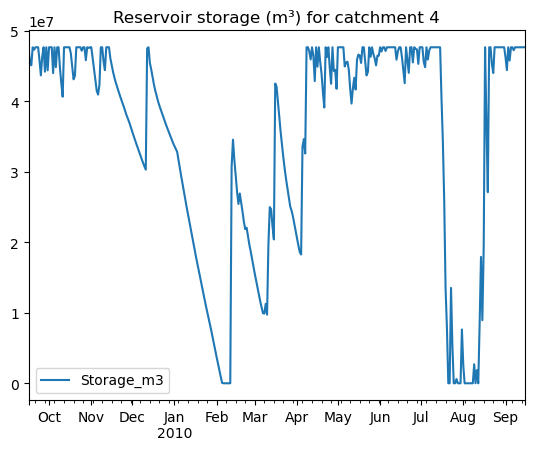

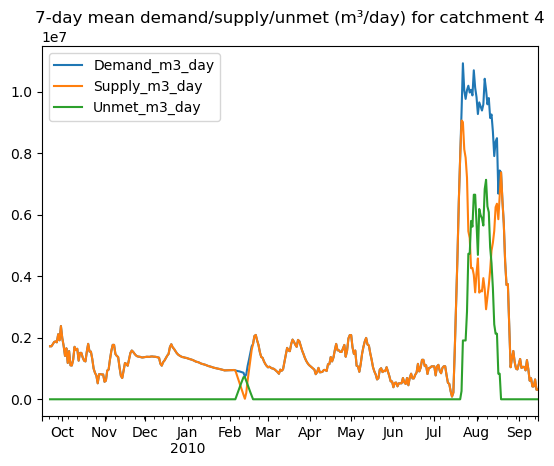

In [483]:
print("For Oti_T5 future scenario for the originally defined catchments:")

surfaceareas2 = []
for i in range(len(catchments)):
    area_catchment = catchments["Areas (m^2)"].iloc[i]
    area_irrigation = catchments["crop_area_m2"].iloc[i]
    model = ReservoirDesignModel(
    percip_df=oti_T5_future,     # or your scenario precip
    evap_df=df_evaporation,      # aligned ET0 series
    kc_combined_md=kc_combined_md,
    area_catchment=area_catchment,
    area_irrigation=area_irrigation,
    Cr=Cr,
    k=k,
    river_q=eval(catchments["River"].iloc[i]),   # design-year river (m3/s)
    diversion=0.30,
    Qdiv_max_m3s=10.0,            # IMPORTANT
    stop_diversion_when_full=True,
    deficit_frac_threshold=0.2,  # or 0.0
    use_soil_bucket=False        # set True when you're ready
    )

    best_area_m2, sim_best, summary = model.find_min_area(
        reservoir_area,
        max_consecutive_failure_days=10,
        S0_frac=1.0
        )

    display(summary)
    surfaceareas2.append(best_area_m2)

    if best_area_m2 is None:
        print("No feasible area found in the candidate set.")
    else:
        print(f"Best area: {best_area_m2:.0f} m² ({best_area_m2/10000:.2f} ha)")
        print(f"Capacity: {volume(best_area_m2):.0f} m³")
        print(f"Max consecutive no-supply days: {model.max_consecutive_failure_days(sim_best)}")

        sim_best[["Storage_m3"]].plot(title=f"Reservoir storage (m³) for catchment {catchments.index[i]}")
        sim_best[["Demand_m3_day","Supply_m3_day","Unmet_m3_day"]].rolling(7).mean().plot(
            title=f"7-day mean demand/supply/unmet (m³/day) for catchment {catchments.index[i]}"
        )
print(f"for Oti_T5 future scenario the sizes of the reservoirs needed for the catchments are (in ha):{[area/10000 for area in surfaceareas2]}")

CHANGE THE CROP AREA BECAUSE THE RESERVOIR SIZES ARE TOO BIG

In [484]:

new_catchments = catchments.copy()

new_catchments["crop_area_m2"] = new_catchments["crop_area_m2"] * 0.5

new_catchments.head()

,Areas (m^2),Region,Precipitation poligon,crop_area_m2,River
Catchments,,,,,
1,5.083914e+09,Upper west,black volta,2.193571e+08,Q_voltarouge_md
2,3.999386e+09,Upper east,pendjari,1.784358e+08,Q_voltablanche_md
3,5.352351e+09,North east region (assumption),Oti,5.616921e+08,Q_voltablanche_md
4,4.343365e+09,Northern,Oti,4.558061e+08,Q_pendjari_md


For Oti_T5 current scenario for the newly defined catchments (croplands reduced by 50%):


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,9.924991e+07,5.598720e+06
1,5.149495e+05,51.494949,1.377441e+06,57,5.680090e+07,5.632046e+06
2,1.019899e+06,101.989899,3.676841e+06,51,3.349581e+07,5.920869e+06
3,1.524848e+06,152.484848,6.552735e+06,42,1.500441e+07,6.180069e+06
4,2.029798e+06,202.979798,9.883216e+06,31,6.937337e+06,6.305966e+06
5,2.534747e+06,253.474747,1.359921e+07,16,3.413655e+06,6.305966e+06
6,3.039697e+06,303.969697,1.765481e+07,0,0.000000e+00,6.305966e+06


Best area: 3039697 m² (303.97 ha)
Capacity: 17654812 m³
Max consecutive no-supply days: 0


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,7.605759e+07,1.302387e+07
1,5.149495e+05,51.494949,1.377441e+06,56,3.809401e+07,1.339786e+07
2,1.019899e+06,101.989899,3.676841e+06,46,1.735749e+07,1.418842e+07
3,1.524848e+06,152.484848,6.552735e+06,34,6.352460e+06,1.526688e+07
4,2.029798e+06,202.979798,9.883216e+06,18,3.194674e+06,1.526688e+07
5,2.534747e+06,253.474747,1.359921e+07,0,0.000000e+00,1.587322e+07


Best area: 2534747 m² (253.47 ha)
Capacity: 13599214 m³
Max consecutive no-supply days: 0


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,2.931715e+08,1.592599e+07
1,5.149495e+05,51.494949,1.377441e+06,59,2.283759e+08,1.609817e+07
2,1.019899e+06,101.989899,3.676841e+06,57,1.764767e+08,1.676931e+07
3,1.524848e+06,152.484848,6.552735e+06,54,1.438201e+08,1.781352e+07
4,2.029798e+06,202.979798,9.883216e+06,50,1.164916e+08,1.844486e+07
5,2.534747e+06,253.474747,1.359921e+07,46,9.257535e+07,1.895215e+07
6,3.039697e+06,303.969697,1.765481e+07,41,7.741489e+07,1.980843e+07
7,3.544646e+06,354.464646,2.201670e+07,37,6.648184e+07,1.987323e+07
8,4.049596e+06,404.959596,2.665933e+07,32,5.762234e+07,1.987323e+07
9,4.554545e+06,455.454545,3.156231e+07,25,4.828433e+07,2.038978e+07


Best area: 5564444 m² (556.44 ha)
Capacity: 42085097 m³
Max consecutive no-supply days: 9


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,39,2.020756e+08,6.846459e+07
1,5.149495e+05,51.494949,1.377441e+06,38,1.294407e+08,8.266999e+07
2,1.019899e+06,101.989899,3.676841e+06,33,9.456892e+07,8.354510e+07
3,1.524848e+06,152.484848,6.552735e+06,27,6.967235e+07,8.613710e+07
4,2.029798e+06,202.979798,9.883216e+06,20,4.730033e+07,8.786510e+07
5,2.534747e+06,253.474747,1.359921e+07,11,3.462950e+07,8.864393e+07
6,3.039697e+06,303.969697,1.765481e+07,2,2.566696e+07,9.111435e+07


Best area: 3039697 m² (303.97 ha)
Capacity: 17654812 m³
Max consecutive no-supply days: 2
for Oti_T5 the sizes of the reservoirs needed for the catchments are (in ha):[303.969696969697, 253.4747474747475, 556.4444444444445, 303.969696969697]


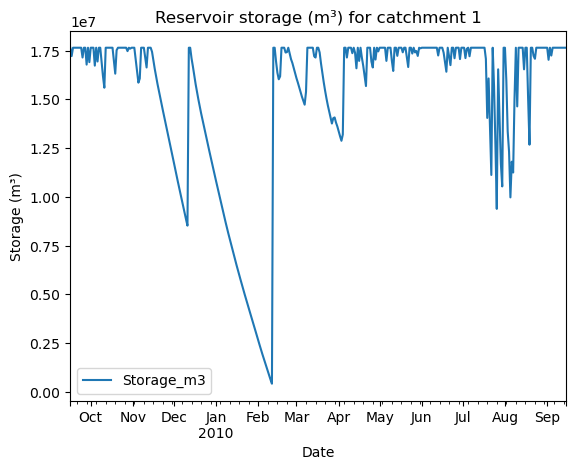

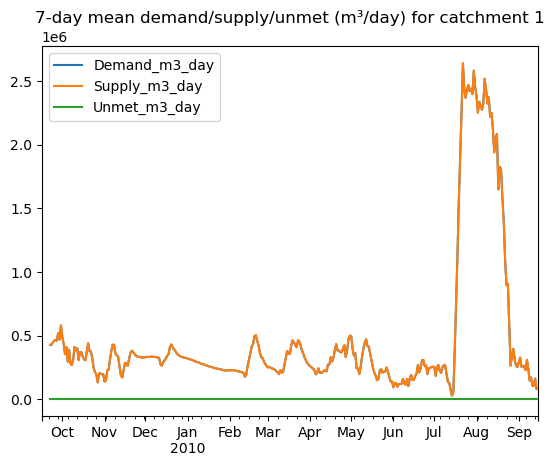

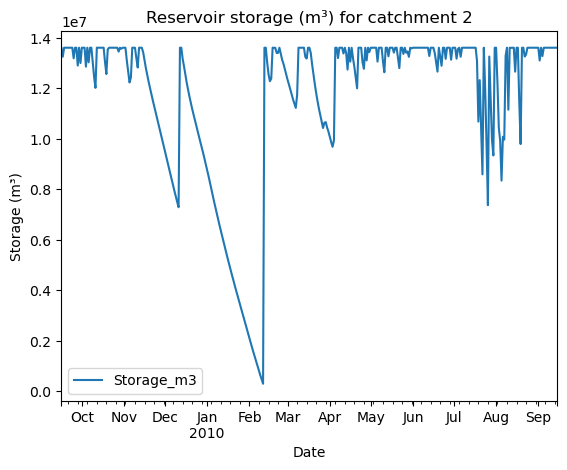

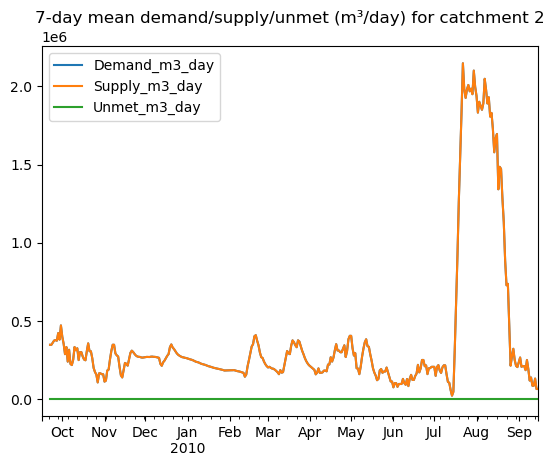

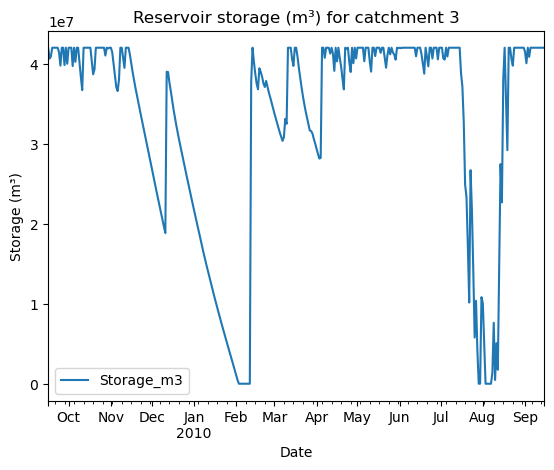

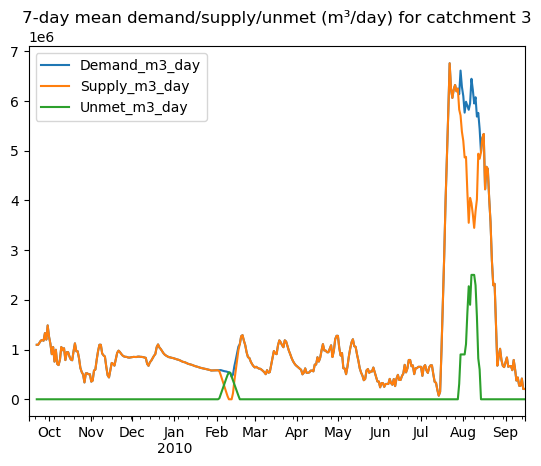

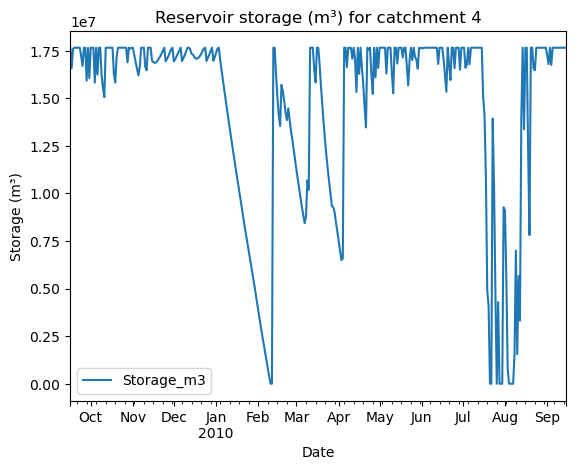

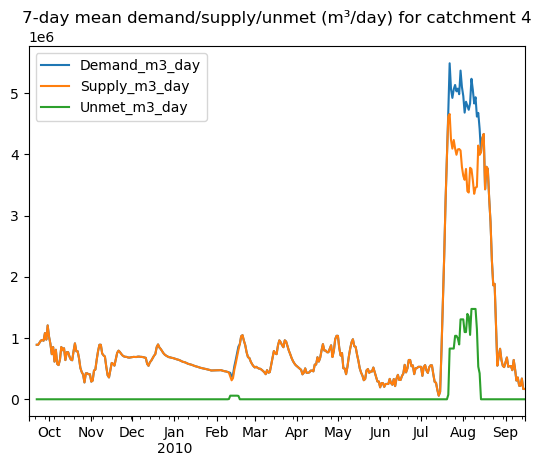

In [485]:
print("For Oti_T5 current scenario for the newly defined catchments (croplands reduced by 50%):")

surfaceareas3 = []
for i in range(len(new_catchments)):
    area_catchment = new_catchments["Areas (m^2)"].iloc[i]
    area_irrigation = new_catchments["crop_area_m2"].iloc[i]
    model = ReservoirDesignModel(
    percip_df=oti_T5,     # or your scenario precip
    evap_df=df_evaporation,      # aligned ET0 series
    kc_combined_md=kc_combined_md,
    area_catchment=area_catchment,
    area_irrigation=area_irrigation,
    Cr=Cr,
    k=k,
    river_q=eval(new_catchments["River"].iloc[i]),   # design-year river (m3/s)
    diversion=0.30,
    Qdiv_max_m3s=10.0,            # IMPORTANT
    stop_diversion_when_full=True,
    deficit_frac_threshold=0.2,  # or 0.0
    use_soil_bucket=False        # set True when you're ready
    )

    best_area_m2, sim_best, summary = model.find_min_area(
        reservoir_area,
        max_consecutive_failure_days=10,
        S0_frac=1.0
        )

    display(summary)
    surfaceareas3.append(best_area_m2)

    if best_area_m2 is None:
        print("No feasible area found in the candidate set.")
    else:
        print(f"Best area: {best_area_m2:.0f} m² ({best_area_m2/10000:.2f} ha)")
        print(f"Capacity: {volume(best_area_m2):.0f} m³")
        print(f"Max consecutive no-supply days: {model.max_consecutive_failure_days(sim_best)}")

        sim_best[["Storage_m3"]].plot(title=f"Reservoir storage (m³) for catchment {new_catchments.index[i]}", xlabel="Date", ylabel="Storage (m³)")
        sim_best[["Demand_m3_day","Supply_m3_day","Unmet_m3_day"]].rolling(7).mean().plot(
            title=f"7-day mean demand/supply/unmet (m³/day) for catchment {new_catchments.index[i]}"
        )


print(f"for Oti_T5 the sizes of the reservoirs needed for the catchments are (in ha):{[area/10000 for area in surfaceareas3]}")

For Oti_T5 future scenario for the newly defined catchments:


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,9.866613e+07,5.598720e+06
1,5.149495e+05,51.494949,1.377441e+06,57,5.645809e+07,5.632046e+06
2,1.019899e+06,101.989899,3.676841e+06,51,3.283139e+07,5.894949e+06
3,1.524848e+06,152.484848,6.552735e+06,42,1.482406e+07,6.120823e+06
4,2.029798e+06,202.979798,9.883216e+06,31,6.937337e+06,6.246720e+06
5,2.534747e+06,253.474747,1.359921e+07,16,3.413655e+06,6.246720e+06
6,3.039697e+06,303.969697,1.765481e+07,0,0.000000e+00,6.272640e+06


Best area: 3039697 m² (303.97 ha)
Capacity: 17654812 m³
Max consecutive no-supply days: 0


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,7.561417e+07,1.302387e+07
1,5.149495e+05,51.494949,1.377441e+06,56,3.782628e+07,1.339786e+07
2,1.019899e+06,101.989899,3.676841e+06,46,1.683060e+07,1.414954e+07
3,1.524848e+06,152.484848,6.552735e+06,34,6.352460e+06,1.414954e+07
4,2.029798e+06,202.979798,9.883216e+06,18,3.194674e+06,1.414954e+07
5,2.534747e+06,253.474747,1.359921e+07,0,0.000000e+00,1.414954e+07


Best area: 2534747 m² (253.47 ha)
Capacity: 13599214 m³
Max consecutive no-supply days: 0


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,60,2.905591e+08,1.592599e+07
1,5.149495e+05,51.494949,1.377441e+06,59,2.255194e+08,1.609817e+07
2,1.019899e+06,101.989899,3.676841e+06,57,1.736910e+08,1.676931e+07
3,1.524848e+06,152.484848,6.552735e+06,54,1.407425e+08,1.781352e+07
4,2.029798e+06,202.979798,9.883216e+06,50,1.134205e+08,1.844486e+07
5,2.534747e+06,253.474747,1.359921e+07,46,8.842394e+07,1.895215e+07
6,3.039697e+06,303.969697,1.765481e+07,41,7.236918e+07,1.895215e+07
7,3.544646e+06,354.464646,2.201670e+07,37,6.073987e+07,1.987323e+07
8,4.049596e+06,404.959596,2.665933e+07,32,5.187900e+07,1.987323e+07
9,4.554545e+06,455.454545,3.156231e+07,25,4.253963e+07,1.987323e+07


Best area: 5564444 m² (556.44 ha)
Capacity: 42085097 m³
Max consecutive no-supply days: 9


,area_m2,area_ha,capacity_m3,max_consec_failure_days,total_unmet_m3,total_river_diverted_m3
0,1.000000e+04,1.000000,4.783886e+03,39,2.000642e+08,6.846459e+07
1,5.149495e+05,51.494949,1.377441e+06,38,1.274121e+08,8.180599e+07
2,1.019899e+06,101.989899,3.676841e+06,33,9.260987e+07,8.354510e+07
3,1.524848e+06,152.484848,6.552735e+06,27,6.719628e+07,8.527310e+07
4,2.029798e+06,202.979798,9.883216e+06,20,4.507481e+07,8.613710e+07
5,2.534747e+06,253.474747,1.359921e+07,11,3.117559e+07,8.777993e+07
6,3.039697e+06,303.969697,1.765481e+07,2,2.102290e+07,9.025035e+07


Best area: 3039697 m² (303.97 ha)
Capacity: 17654812 m³
Max consecutive no-supply days: 2
for Oti_T5 future scenario the sizes of the reservoirs needed for the catchments are (in ha):[303.969696969697, 253.4747474747475, 556.4444444444445, 303.969696969697]


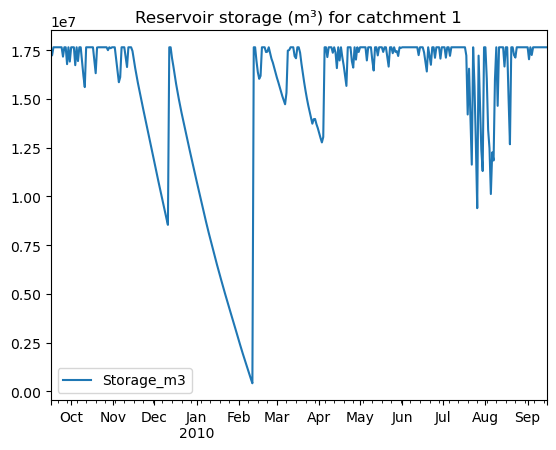

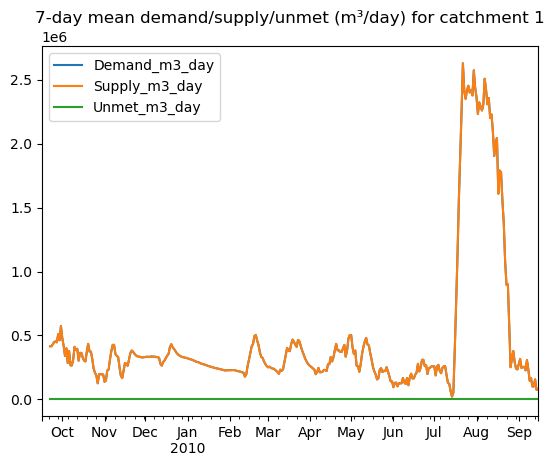

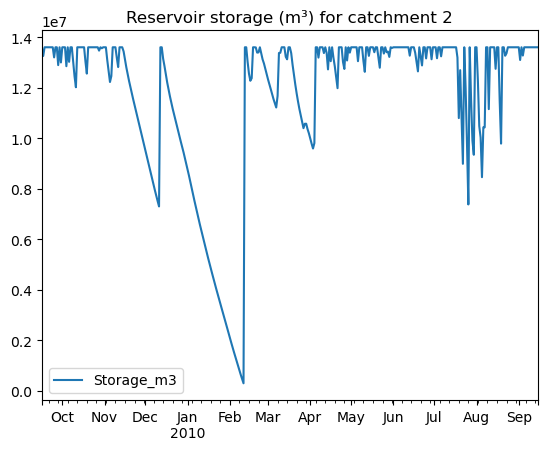

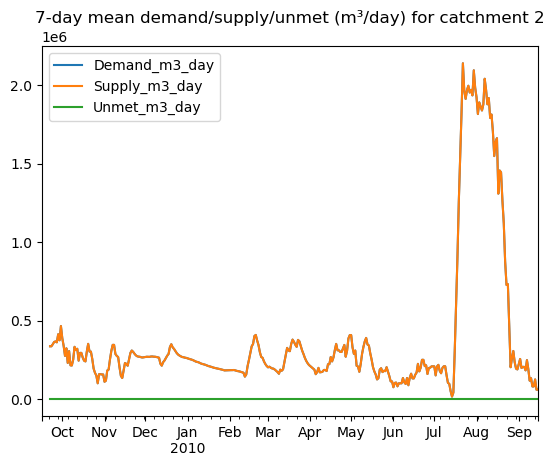

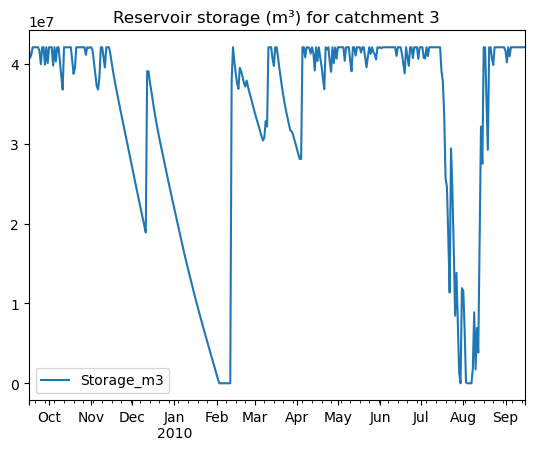

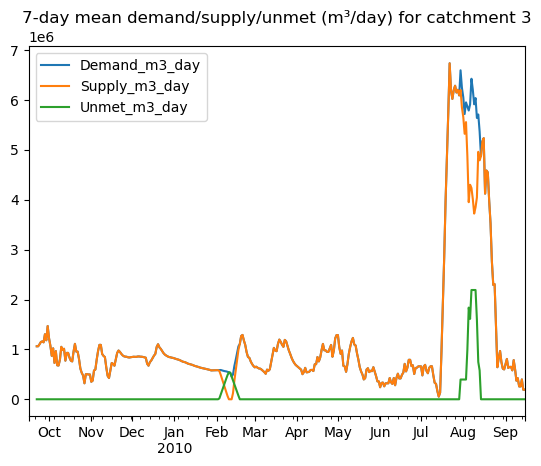

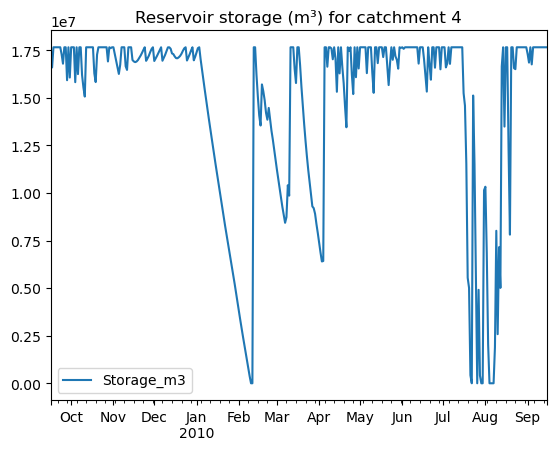

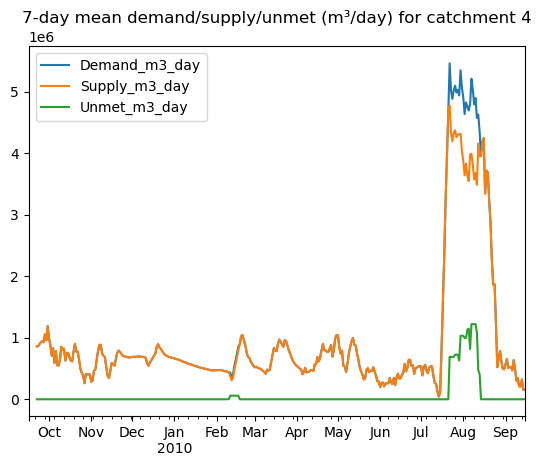

In [486]:
print("For Oti_T5 future scenario for the newly defined catchments:")

surfaceareas4 = []
for i in range(len(new_catchments)):
    area_catchment = new_catchments["Areas (m^2)"].iloc[i]
    area_irrigation = new_catchments["crop_area_m2"].iloc[i]
    model = ReservoirDesignModel(
    percip_df=oti_T5_future,     # or your scenario precip
    evap_df=df_evaporation,      # aligned ET0 series
    kc_combined_md=kc_combined_md,
    area_catchment=area_catchment,
    area_irrigation=area_irrigation,
    Cr=Cr,
    k=k,
    river_q=eval(new_catchments["River"].iloc[i]),   # design-year river (m3/s)
    diversion=0.30,
    Qdiv_max_m3s=10.0,            # IMPORTANT
    stop_diversion_when_full=True,
    deficit_frac_threshold=0.2,  # or 0.0
    use_soil_bucket=False        # set True when you're ready
    )

    best_area_m2, sim_best, summary = model.find_min_area(
        reservoir_area,
        max_consecutive_failure_days=10,
        S0_frac=1.0
        )

    display(summary)
    surfaceareas4.append(best_area_m2)

    if best_area_m2 is None:
        print("No feasible area found in the candidate set.")
    else:
        print(f"Best area: {best_area_m2:.0f} m² ({best_area_m2/10000:.2f} ha)")
        print(f"Capacity: {volume(best_area_m2):.0f} m³")
        print(f"Max consecutive no-supply days: {model.max_consecutive_failure_days(sim_best)}")

        sim_best[["Storage_m3"]].plot(title=f"Reservoir storage (m³) for catchment {new_catchments.index[i]}")
        sim_best[["Demand_m3_day","Supply_m3_day","Unmet_m3_day"]].rolling(7).mean().plot(
            title=f"7-day mean demand/supply/unmet (m³/day) for catchment {new_catchments.index[i]}"
        )
print(f"for Oti_T5 future scenario the sizes of the reservoirs needed for the catchments are (in ha):{[area/10000 for area in surfaceareas4]}")

In [487]:
print("OTI_5 original basins:", [area/10000 for area in surfaceareas])
print("OTI_5 future basins:", [area/10000 for area in surfaceareas2])
print("OTI_5 reduced cropland basins:", [area/10000 for area in surfaceareas3])
print("OTI_5 future reduced cropland basins:", [area/10000 for area in surfaceareas4])

OTI_5 original basins: [455.4545454545455, 404.95959595959596, 1061.3939393939395, 606.939393939394]
OTI_5 future basins: [455.4545454545455, 404.95959595959596, 1061.3939393939395, 606.939393939394]
OTI_5 reduced cropland basins: [303.969696969697, 253.4747474747475, 556.4444444444445, 303.969696969697]
OTI_5 future reduced cropland basins: [303.969696969697, 253.4747474747475, 556.4444444444445, 303.969696969697]


Now we will take the defined surface areas and test these for drought resistance in a T50 year. The surface areas of the catchments will remain constant to the surfaceareas4, and a new percipitation data will be applied to check for how long the reservoirs will be empty.

In [488]:

EMPTY_TOL = 1e-6  # m3, treat <= this as empty

print("Testing the newly defined catchments on an Oti_T50 scenario:")

rows = []

for i in range(len(new_catchments)):
    area_catchment = new_catchments["Areas (m^2)"].iloc[i]
    area_irrigation = new_catchments["crop_area_m2"].iloc[i]

    # The designed reservoir surface area (m2) from your last T5 sizing run
    area_res_m2 = float(surfaceareas4[i])

    # River design-year series stored as a string name in the dataframe
    river_name = new_catchments["River"].iloc[i]
    river_q = eval(river_name)

    # Build model with Oti_T50 precipitation forcing
    model = ReservoirDesignModel(
        percip_df=oti_T50,            # <-- T50 precipitation series
        evap_df=df_evaporation,
        kc_combined_md=kc_combined_md,
        area_catchment=area_catchment,  
        area_irrigation=area_irrigation,
        Cr=Cr,
        k=k,
        river_q=river_q,
        diversion=0.30,
        Qdiv_max_m3s=10.0,
        stop_diversion_when_full=True,
        deficit_frac_threshold=0.2,
        use_soil_bucket=False
    )

    # Run the simulation at the fixed (designed) area
    sim = model.simulate(area_m2=area_res_m2, S0_frac=1.0)

    # ---- Metrics: "how often empty" ----
    empty = sim["Storage_m3"] <= EMPTY_TOL
    empty_days = int(empty.sum())
    total_days = int(len(sim))
    empty_frac = empty_days / total_days if total_days else np.nan

    # Max consecutive empty days
    max_empty_run = run = 0
    for v in empty.to_numpy():
        if v:
            run += 1
            max_empty_run = max(max_empty_run, run)
        else:
            run = 0

    # ---- Metric: max consecutive failure days (your deficit threshold) ----
    max_fail_run = model.max_consecutive_failure_days(sim)

    # Collect summary
    rows.append({
        "catchment_index": i,
        "catchment_name": new_catchments["Catchment"].iloc[i] if "Catchment" in new_catchments.columns else f"catchment_{i}",
        "river": river_name,
        "area_catchment_m2": area_catchment,
        "area_irrigation_m2": area_irrigation,
        "reservoir_area_m2_T5designed": area_res_m2,
        "capacity_m3": float(sim["Capacity_m3"].iloc[0]) if "Capacity_m3" in sim.columns else np.nan,
        "empty_days_T50": empty_days,
        "empty_fraction_T50": empty_frac,
        "max_consecutive_empty_days_T50": int(max_empty_run),
        "max_consec_failure_days_T50": int(max_fail_run),
        "total_unmet_m3_T50": float(sim["Unmet_m3_day"].sum()),
        "total_river_diverted_m3_T50": float(sim["RiverDiversion_m3_day"].sum()) if "RiverDiversion_m3_day" in sim.columns else np.nan,
        "min_storage_m3_T50": float(sim["Storage_m3"].min()),
    })

    # Optional: show a small per-catchment snapshot
    print(f"\nCatchment {i}: res_area={area_res_m2:.0f} m², empty_days={empty_days}, max_empty_run={max_empty_run}, max_fail_run={max_fail_run}")
    # display(sim.head(5))  # uncomment if you want

summary_T50 = pd.DataFrame(rows)
display(summary_T50)

Testing the newly defined catchments on an Oti_T50 scenario:

Catchment 0: res_area=3039697 m², empty_days=14, max_empty_run=14, max_fail_run=14

Catchment 1: res_area=2534747 m², empty_days=12, max_empty_run=12, max_fail_run=12

Catchment 2: res_area=5564444 m², empty_days=58, max_empty_run=35, max_fail_run=35

Catchment 3: res_area=3039697 m², empty_days=37, max_empty_run=29, max_fail_run=29


,catchment_index,catchment_name,river,area_catchment_m2,area_irrigation_m2,reservoir_area_m2_T5designed,capacity_m3,empty_days_T50,empty_fraction_T50,max_consecutive_empty_days_T50,max_consec_failure_days_T50,total_unmet_m3_T50,total_river_diverted_m3_T50,min_storage_m3_T50
0,0,catchment_0,Q_voltarouge_md,5.083914e+09,2.193571e+08,3.039697e+06,1.765481e+07,14,0.038356,14,14,2.248946e+06,9.007200e+06,0.0
1,1,catchment_1,Q_voltablanche_md,3.999386e+09,1.784358e+08,2.534747e+06,1.359921e+07,12,0.032877,12,12,1.517965e+06,1.775520e+07,0.0
2,2,catchment_2,Q_voltablanche_md,5.352351e+09,5.616921e+08,5.564444e+06,4.208510e+07,58,0.158904,35,35,3.204860e+07,2.250597e+07,0.0
3,3,catchment_3,Q_pendjari_md,4.343365e+09,4.558061e+08,3.039697e+06,1.765481e+07,37,0.101370,29,29,3.158112e+07,9.420809e+07,0.0


In [489]:

EMPTY_TOL = 1e-6  # m3, treat <= this as empty

print("Testing the newly defined catchments on an Oti_T50_future scenario:")

rows2 = []

for i in range(len(new_catchments)):
    area_catchment = new_catchments["Areas (m^2)"].iloc[i]
    area_irrigation = new_catchments["crop_area_m2"].iloc[i]

    # The designed reservoir surface area (m2) from your last T5 sizing run
    area_res_m2 = float(surfaceareas4[i])

    # River design-year series stored as a string name in the dataframe
    river_name = new_catchments["River"].iloc[i]
    river_q = eval(river_name)

    # Build model with Oti_T50 precipitation forcing
    model = ReservoirDesignModel(
        percip_df=oti_T50_future,            # <-- T50 future precipitation series
        evap_df=df_evaporation,
        kc_combined_md=kc_combined_md,
        area_catchment=area_catchment,  
        area_irrigation=area_irrigation,
        Cr=Cr,
        k=k,
        river_q=river_q,
        diversion=0.30,
        Qdiv_max_m3s=10.0,
        stop_diversion_when_full=True,
        deficit_frac_threshold=0.2,
        use_soil_bucket=False
    )

    # Run the simulation at the fixed (designed) area
    sim = model.simulate(area_m2=area_res_m2, S0_frac=1.0)

    # ---- Metrics: "how often empty" ----
    empty = sim["Storage_m3"] <= EMPTY_TOL
    empty_days = int(empty.sum())
    total_days = int(len(sim))
    empty_frac = empty_days / total_days if total_days else np.nan

    # Max consecutive empty days
    max_empty_run = run = 0
    for v in empty.to_numpy():
        if v:
            run += 1
            max_empty_run = max(max_empty_run, run)
        else:
            run = 0

    # ---- Metric: max consecutive failure days (your deficit threshold) ----
    max_fail_run = model.max_consecutive_failure_days(sim)

    # Collect summary
    rows2.append({
        "catchment_index": i,
        "area_catchment_m2": area_catchment,
        "area_irrigation_m2": area_irrigation,
        "reservoir_area_m2_T5designed": area_res_m2,
        "capacity_m3": float(sim["Capacity_m3"].iloc[0]) if "Capacity_m3" in sim.columns else np.nan,
        "empty_days_T50_future": empty_days,
        "empty_fraction_T50_future": empty_frac,
        "max_consecutive_empty_days_T50_future": int(max_empty_run),
        "max_consec_failure_days_T50_future": int(max_fail_run),
        "total_unmet_m3_T50_future": float(sim["Unmet_m3_day"].sum()),
    })

    # Optional: show a small per-catchment snapshot
    print(f"\nCatchment {i}: res_area={area_res_m2:.0f} m², empty_days={empty_days}, max_empty_run={max_empty_run}, max_fail_run={max_fail_run}")
    # display(sim.head(5))  # uncomment if you want

summary_T50_future = pd.DataFrame(rows2)
display(summary_T50_future)

Testing the newly defined catchments on an Oti_T50_future scenario:

Catchment 0: res_area=3039697 m², empty_days=14, max_empty_run=14, max_fail_run=14

Catchment 1: res_area=2534747 m², empty_days=12, max_empty_run=12, max_fail_run=12

Catchment 2: res_area=5564444 m², empty_days=56, max_empty_run=35, max_fail_run=35

Catchment 3: res_area=3039697 m², empty_days=36, max_empty_run=29, max_fail_run=29


,catchment_index,area_catchment_m2,area_irrigation_m2,reservoir_area_m2_T5designed,capacity_m3,empty_days_T50_future,empty_fraction_T50_future,max_consecutive_empty_days_T50_future,max_consec_failure_days_T50_future,total_unmet_m3_T50_future
0,0,5.083914e+09,2.193571e+08,3.039697e+06,1.765481e+07,14,0.038356,14,14,2.256618e+06
1,1,3.999386e+09,1.784358e+08,2.534747e+06,1.359921e+07,12,0.032877,12,12,1.524013e+06
2,2,5.352351e+09,5.616921e+08,5.564444e+06,4.208510e+07,56,0.153425,35,35,3.041170e+07
3,3,4.343365e+09,4.558061e+08,3.039697e+06,1.765481e+07,36,0.098630,29,29,3.035696e+07
